The bad result is:
{}


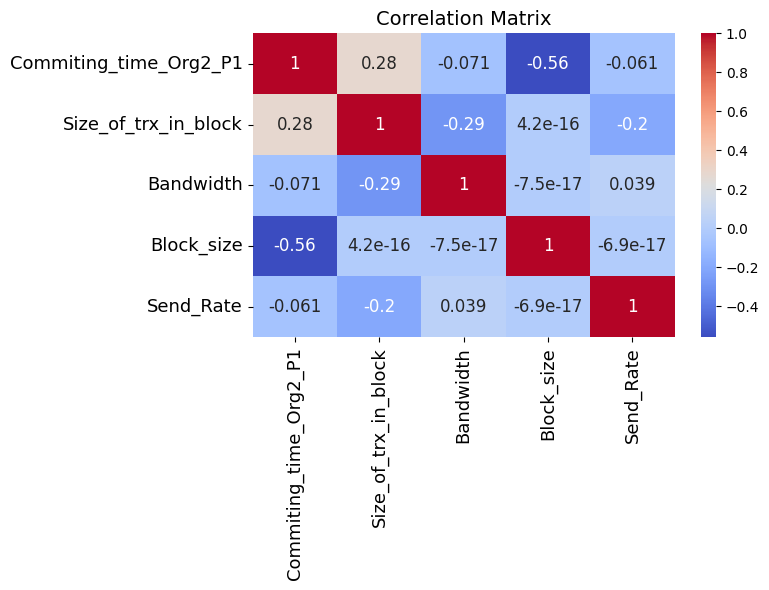

Correlation with 'Commiting_time_Org2_P1':
Commiting_time_Org2_P1    1.000000
throuout                  0.549179
Size_of_trx_in_block      0.276714
Send_Rate                -0.061424
Bandwidth                -0.070792
latancy                  -0.467275
Block_size               -0.558895
Name: Commiting_time_Org2_P1, dtype: float64

Feature Importances:
                Feature  Importance
2            Block_size    0.715078
3             Send_Rate    0.121048
0  Size_of_trx_in_block    0.096609
1             Bandwidth    0.067264

Top 2 Features:
['Block_size', 'Send_Rate']


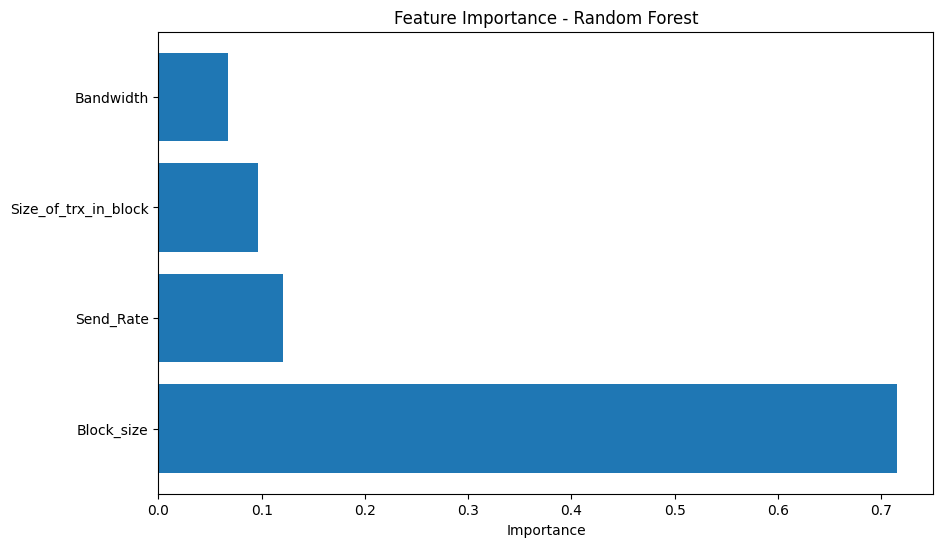

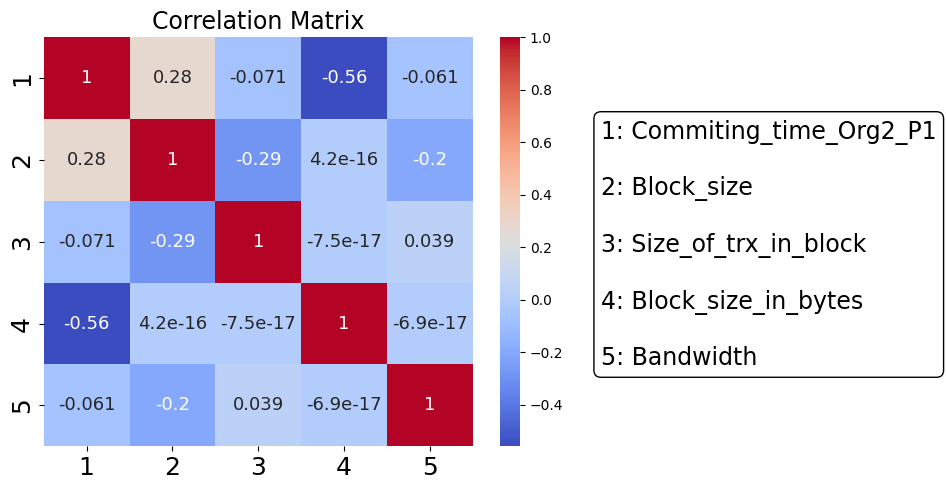

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'pdf.fonttype': 42})
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ---- Your dataset ----
data = {


     "Size_of_trx_in_block": [2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                              
                            2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                              
                              4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                              
                              4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                             
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                              
                              8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              
                                8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                               8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                    
                             
                             
                             
                        ],
    "Bandwidth": [1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                   5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                   20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  
                          1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                    5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
 
                 ],
    "Block_size":[2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                   2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                  
                   2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                 ],
    "Send_Rate":[10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,
                 300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,
                 
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,
                 300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,
                 
             
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,
                 300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,
                 
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                  10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                    10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                  10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
             
             
                ],


     
       "Commiting_time_Org2_P1": [

              0.001941049,
0.001757926,
0.001621167,
0.001637598,
0.001565367,
0.00121697,
0.001213853,
0.001110765,
0.001025275,
0.001327094,
0.001081797,
0.000976034,
0.001155317,
0.00101437,
0.001366017,
0.001999326,
0.001847405,
0.001679831,
0.001546575,
0.001624183,
0.001395871,
0.001355845,
0.001639687,
0.00143553,
0.001047202,
0.001020071,
0.00094536,
0.001060371,
0.00112076,
0.001004656,
0.00164764,
0.001788679,
0.001446204,
0.001500648,
0.001372742,
0.001322554,
0.001257606,
0.001491526,
0.001387142,
0.001020821,
0.000964267,
0.001303198,
0.001045117,
0.001270986,
0.001113806,
0.001824239,
0.001934894,
0.001489533,
0.001759193,
0.001337787,
0.001372462,
0.001303492,
0.001461362,
0.00116651,
0.001067327,
0.001099089,
0.001056264,
0.001077094,
0.001124103,
0.001169562,
0.001795208,
0.001745913,
0.001608658,
0.00147736,
0.001793392,
0.001581285,
0.001333966,
0.001707781,
0.001235839,
0.001047543,
0.001032413,
0.001126275,
0.001000944,
0.000983474,
0.001039292,
0.001776534,
0.001383757,
0.00130539,
0.001625666,
0.001738183,
0.001180819,
0.001517289,
0.001660605,
0.001462088,
0.001106782,
0.001048291,
0.001026522,
0.001101806,
0.001024953,
0.001086819,
0.001643944,
0.001662106,
0.001683304,
0.001753742,
0.002091195,
0.001546787,
0.00133624,
0.001295322,
0.001622562,
0.001142521,
0.00100758,
0.001056755,
0.001101848,
0.001062138,
0.001404485,
0.001753742,
0.001605721,
0.001308058,
0.001499679,
0.001816708,
0.001661137,
0.00122162,
0.001305507,
0.001294017,
0.001064775,
0.001224976,
0.001243242,
0.001066694,
0.001242435,
0.000973066,
0.001964777,
0.0016143,
0.001423581,
0.001365513,
0.001299231,
0.001293228,
0.001263643,
0.001273607,
0.0013401,
0.001018706,
0.00097109,
0.00106782,
0.001043847,
0.001135078,
0.001108591,
0.001620948,
0.001888244,
0.00142231,
0.001779942,
0.001873242,
0.001220706,
0.001168662,
0.001097778,
0.001603748,
0.001294092,
0.00112035,
0.001090895,
0.000992939,
0.001239277,
0.001109262,
0.001620948,
0.001888244,
0.00142231,
0.001779942,
0.001873242,
0.001220706,
0.001168662,
0.001097778,
0.001603748,
0.001294092,
0.00112035,
0.001090895,
0.000992939,
0.001239277,
0.001109262,
0.002047284,
0.001612307,
0.001614116,
0.001492245,
0.001323577,
0.001157469,
0.00121869,
0.00111448,
0.001203563,
0.001047746,
0.001022312,
0.000990883,
0.001032587,
0.001300751,
0.001105326,
0.001655554,
0.001672416,
0.001521905,
0.001477818,
0.001289181,
0.001508649,
0.001250929,
0.001154856,
0.001345483,
0.001456191,
0.001080494,
0.001067268,
0.001079736,
0.001056476,
0.001133249,
0.001959,
0.001685411,
0.001600907,
0.00159111,
0.001656761,
0.001206845,
0.001306284,
0.001126212,
0.001146101,
0.001040634,
0.001099346,
0.001101155,
0.001039286,
0.001064894,
0.001094058,
0.001853615,
0.001605705,
0.00152589,
0.001508538,
0.001752316,
0.001372875,
0.001324676,
0.001515933,
0.001333312,
0.001044604,
0.001073123,
0.001003434,
0.001127164,
0.001064439,
0.00098187,
0.001738277,
0.001635424,
0.001626486,
0.001877588,
0.001506561,
0.001275436,
0.001397188,
0.001459052,
0.001331602,
0.00118748,
0.000977203,
0.001058128,
0.001236587,
0.001019705,
0.001295259,
0.001848257,
0.001542663,
0.001456594,
0.001453189,
0.001626805,
0.001276022,
0.0015781,
0.00128789,
0.001145777,
0.001199582,
0.001072265,
0.001114855,
0.001241694,
0.001066594,
0.001236353,
0.001736904,
0.001575466,
0.001343981,
0.001423217,
0.001951686,
0.00129659,
0.00135021,
0.001384398,
0.001383319,
0.001066565,
0.001077877,
0.0011223,
0.001151913,
0.001124544,
0.001039825,
0.001923124,
0.00212143,
0.001735931,
0.001607127,
0.001860403,
0.001326801,
0.001279614,
0.00125816,
0.001092732,
0.001067569,
0.00096176,
0.00113451,
0.001078193,
0.001220414,
0.001107873,
0.001811742,
0.001791447,
0.001516854,
0.001582853,
0.001810166,
0.001233996,
0.001348673,
0.00124389,
0.001205178,
0.00118197,
0.001229862,
0.001088395,
0.001216607,
0.001208015,
0.001154723,
0.001784025,
0.001684585,
0.00146492,
0.001466929,
0.00179203,
0.001219917,
0.001209713,
0.001221479,
0.001298456,
0.00102341,
0.001098391,
0.00098893,
0.001039377,
0.001132349,
0.000994539,
0.001864289,
0.001883285,
0.00153815,
0.001427257,
0.001652155,
0.001290861,
0.001337641,
0.001459744,
0.001169479,
0.001074583,
0.001010203,
0.001170398,
0.001019554,
0.00109004,
0.000959681,
0.001703199,
0.001659848,
0.001602582,
0.001831251,
0.0013896,
0.001373492,
0.001987136,
0.001380741,
0.001216368,
0.000996946,
0.001087005,
0.001007101,
0.0010347,
0.001210504,
0.00095906,
0.001665763,
0.001818028,
0.001391774,
0.001454411,
0.001573048,
0.001449489,
0.001199128,
0.001331837,
0.001257416,
0.001074619,
0.001042391,
0.001324236,
0.001206753,
0.001177617,
0.001282312,
0.002149609,
0.001926381,
0.001544744,
0.001381669,
0.00193385,
0.001371229,
0.001230757,
0.001416156,
0.001529082,
0.002075658,
0.001168824,
0.001352284,
0.00109937,
0.001078887,
0.001277029,
0.001953733,
0.001728996,
0.001381403,
0.001481675,
0.001875034,
0.001355837,
0.001351068,
0.001306286,
0.001598051,
0.001185502,
0.001125943,
0.001059622,
0.00117193,
0.001116104,
0.001037547,
0.001733135,
0.001815822,
0.001661979,
0.002011518,
0.001829734,
0.001753824,
0.001243798,
0.001345933,
0.001542517,
0.001245173,
0.001116873,
0.001260812,
0.00121346,
0.001071327,
0.00122383,
0.001829135,
0.001771465,
0.001713566,
0.001520939,
0.002139754,
0.001474921,
0.00156919,
0.001255085,
0.001838808,
0.00119593,
0.001129275,
0.001110386,
0.001365644,
0.001147293,
0.001215586,
0.001930371,
0.001989964,
0.001654993,
0.001459429,
0.001607889,
0.00139369,
0.001492046,
0.001645521,
0.001640256,
0.001276964,
0.001036339,
0.001340801,
0.001138914,
0.001263916,
0.001070343,
0.001965039,
0.001708109,
0.001564904,
0.001474893,
0.00170357,
0.001358556,
0.001500246,
0.001448198,
0.001418951,
0.001558643,
0.00117355,
0.001169231,
0.001284217,
0.001114092,
0.001142285,
0.001868523,
0.0016385,
0.001924675,
0.001743462,
0.001533025,
0.001394693,
0.001153455,
0.001172867,
0.002244262,
0.001069082,
0.001199358,
0.001403292,
0.001445806,
0.001173399,
0.001172103,
0.001727333,
0.001643104,
0.001656934,
0.001441154,
0.001453409,
0.001136558,
0.001174157,
0.00120775,
0.001268659,
0.001084927,
0.001185377,
0.001015448,
0.00113397,
0.001222187,
0.001108573,
0.001979433,
0.001763866,
0.001629101,
0.00166457,
0.001458498,
0.001505478,
0.001419337,
0.001611984,
0.001464034,
0.001413461,
0.001271494,
0.001178473,
0.001137666,
0.001058165,
0.001196937,
0.002093744,
0.001806431,
0.001653136,
0.001587696,
0.00174016,
0.001435327,
0.001377927,
0.001325873,
0.001267284,
0.001472456,
0.001313769,
0.001090517,
0.001122793,
0.001069189,
0.001132895,
0.001804877,
0.001940041,
0.00154234,
0.00167755,
0.001817284,
0.001436647,
0.001231696,
0.001348889,
0.001165929,
0.001735885,
0.00111537,
0.001229063,
0.001255668,
0.001132523,
0.001021647,
0.001890455,
0.001773309,
0.00162288,
0.001295058,
0.001583429,
0.001463189,
0.001144133,
0.001265422,
0.001596962,
0.001157414,
0.001015031,
0.00124168,
0.001106849,
0.001096461,
0.00103015,
0.002059324,
0.001675147,
0.001571839,
0.001609594,
0.001517676,
0.001456677,
0.001397716,
0.001621273,
0.001549789,
0.001201085,
0.001128555,
0.001196213,
0.001075972,
0.001213563,
0.001131951,
0.001924302,
0.001889027,
0.001519621,
0.001605833,
0.001877777,
0.001452789,
0.001367062,
0.001890855,
0.001406886,
0.001090374,
0.001280937,
0.001203951,
0.001166767,
0.001253001,
0.001191159,
0.001994404,
0.001830798,
0.001720408,
0.00145868,
0.001575045,
0.001254713,
0.001173057,
0.001497092,
0.001518906,
0.001173582,
0.001172534,
0.001163917,
0.001341445,
0.001035966,
0.00142659,
0.002094821,
0.002376881,
0.001610778,
0.001571449,
0.00159818,
0.001303316,
0.001257356,
0.001310026,
0.001575486,
0.001166917,
0.001153081,
0.001234272,
0.001259153,
0.001403157,
0.001142495,
0.00195442,
0.002087034,
0.001537312,
0.001626696,
0.001912313,
0.001505916,
0.001227335,
0.001165578,
0.001335821,
0.001306854,
0.001440995,
0.001097469,
0.001052301,
0.0013545,
0.001198938,
0.001990847,
0.001734577,
0.001544672,
0.001820583,
0.001542609,
0.001171955,
0.001173269,
0.001460892,
0.001994309,
0.001390673,
0.001051244,
0.001145518,
0.001114462,
0.001147527,
0.001248503,
0.002063108,
0.002056955,
0.001555741,
0.00189887,
0.002211046,
0.001548755,
0.001587069,
0.001314027,
0.001278368,
0.001373172,
0.001317927,
0.00131921,
0.001272345,
0.001338859,
0.001413115,
0.001825229,
0.001948813,
0.001598262,
0.001739039,
0.001667581,
0.0013274,
0.001717376,
0.001494007,
0.001616867,
0.001285656,
0.001253889,
0.001396579,
0.001248017,
0.001313476,
0.001261346,
0.002036108,
0.001974624,
0.001971572,
0.002000159,
0.001744333,
0.001294933,
0.001248917,
0.001569665,
0.00163186,
0.001284524,
0.001437429,
0.001403832,
0.001300605,
0.001244412,
0.001247364,
0.00195905,
0.002121429,
0.001828927,
0.001568942,
0.001756363,
0.00145739,
0.001228156,
0.001237707,
0.001597684,
0.001436361,
0.001265075,
0.001172312,
0.001336512,
0.001386387,
0.001229585,
0.001963063,
0.001783528,
0.001758765,
0.001565859,
0.001502043,
0.001558982,
0.001399111,
0.001885274,
0.002175257,
0.001152714,
0.001559753,
0.001390918,
0.001152768,
0.001382918,
0.001650722,
0.001934898,
0.001828737,
0.001875721,
0.001751605,
0.00184878,
0.001547436,
0.001432839,
0.00137566,
0.00156084,
0.001204362,
0.001123149,
0.001334624,
0.001222884,
0.001257911,
0.001546294,
0.002071918,
0.002137262,
0.001967069,
0.0014938,
0.00185261,
0.001475634,
0.001667544,
0.001303095,
0.001448818,
0.001391764,
0.001239518,
0.001577833,
0.0012398,
0.001558989,
0.001380932,
0.002152427,
0.002409588,
0.001726119,
0.001642844,
0.002252367,
0.001567309,
0.001366327,
0.001538248,
0.001892278,
0.001147236,
0.001348204,
0.001400868,
0.001279079,
0.001290932,
0.00136632,
0.001967418,
0.002031656,
0.001772059,
0.001744263,
0.00172507,
0.001616757,
0.001519823,
0.001390356,
0.002455102,
0.001149317,
0.001165121,
0.001495608,
0.001332675,
0.00148606,
0.001286188,
0.002193137,
0.002018061,
0.001783404,
0.001784606,
0.001813264,
0.001481304,
0.001400438,
0.001384383,
0.001254567,
0.001236224,
0.00124834,
0.001299054,
0.00129945,
0.001520408,
0.001512539,
0.002156248,
0.002097679,
0.001597182,
0.001732087,
0.001653531,
0.00160413,
0.00141275,
0.001361598,
0.001372218,
0.001242839,
0.001258144,
0.001238336,
0.001301633,
0.001364715,
0.001351858,
0.001798771,
0.00184761,
0.001582069,
0.001897017,
0.002018321,
0.00122721,
0.001514263,
0.001428727,
0.001378788,
0.001927238,
0.001233308,
0.00155038,
0.00127933,
0.001646975,
0.001396397,
                               ],
    
    
    
    
    
        "throuout":[35,
35,
32.4,
28.9,
34.8,
56.9,
23.4,
24.4,
21.7,
14.8,
5,
2.2,
0.7,
0.6,
0.6,
33.1,
33.3,
31.7,
28.5,
32.1,
68.5,
24.4,
24.9,
24.9,
12.5,
4.2,
2.1,
0.7,
0.6,
0.7,
35,
35.4,
31.5,
29.4,
33.3,
57,
25.1,
22.2,
19.5,
10.6,
5.2,
2.1,
0.7,
0.7,
0.7,
35.1,
35.2,
31.1,
27.8,
33.3,
53.4,
25,
22.3,
21.6,
19.7,
6,
2.2,
0.7,
0.7,
0.6,
34.9,
35.1,
32.5,
26.7,
34.4,
52.3,
28.1,
23.2,
23.8,
16.2,
5.1,
1.5,
0.6,
0.7,
0.6,
35.1,
35.2,
31.6,
28.5,
34.7,
46.3,
25.7,
26.5,
25.4,
16,
3.7,
2.1,
0.7,
0.6,
0.6,
35.2,
35,
31.8,
25.7,
33.6,
67.6,
24.3,
24.3,
24,
16.5,
5.3,
2.2,
0.7,
0.6,
0.7,
35.2,
35.4,
31.6,
27.6,
34.5,
70.5,
26.2,
24.2,
21.4,
13.5,
5.6,
2.2,
0.6,
0.6,
0.7,
                    
                    34.6,
35.2,
31.7,
29.3,
33.8,
76.9,
24.7,
26.9,
24,
15.5,
3,
2.2,
0.6,
0.7,
0.6,
35.1,
35.4,
32.2,
30.6,
34.5,
72.8,
26.8,
26.3,
23.9,
12.9,
3.7,
1.4,
0.6,
0.6,
0.7,
35.1,
35.4,
32.2,
30.6,
34.5,
72.8,
26.8,
26.3,
23.9,
12.9,
3.7,
1.4,
0.6,
0.6,
0.7,
35,
35.1,
32.3,
27.4,
34.5,
64.9,
11.9,
25.9,
20.4,
12.8,
3.7,
2.2,
0.7,
0.7,
0.7,
34.9,
35,
31.9,
26.7,
33.1,
65,
26.4,
24.1,
17.7,
14.7,
2.8,
1.5,
0.7,
0.7,
0.7,
35.1,
34.8,
32.1,
27.3,
34.5,
55.2,
26,
26.2,
23,
17.8,
5.7,
2.2,
0.7,
0.7,
0.6,
35,
35.2,
32.8,
29.8,
34.5,
51.9,
24.7,
27.1,
23.8,
16.6,
3.7,
1.5,
0.7,
0.6,
0.7,
35,
34.9,
33,
27.7,
34.8,
63.4,
27,
25.7,
21.2,
18.6,
5.3,
2.2,
0.7,
0.7,
0.7,
                    35.4,
35.3,
31.8,
29.2,
34.6,
51.9,
26.5,
25.9,
22.7,
15.5,
3.3,
2.2,
0.7,
0.6,
0.6,
34.9,
35.1,
32.6,
27,
33.4,
59.7,
26.5,
18.7,
22.6,
12.5,
3,
1.5,
0.6,
0.7,
0.7,
33.9,
34.5,
32,
27.8,
33.4,
43.6,
23.4,
27.4,
13.2,
16.8,
4.1,
1.4,
0.7,
0.7,
0.6,
34.7,
34.7,
32.4,
29.7,
34.2,
74.8,
25.8,
24.5,
19.4,
19.3,
4.8,
2.2,
0.7,
0.7,
0.6,
34.9,
35.2,
31.5,
29.8,
34.6,
59.9,
29.5,
22.6,
22,
19.2,
4.2,
1.4,
0.7,
0.6,
0.6,
34.5,
35.1,
32.5,
30,
33.6,
64.7,
27.1,
20.6,
25.4,
18.5,
5.2,
2.2,
0.7,
0.7,
0.7,
34.6,
35.2,
32.3,
28.4,
34.7,
64.3,
25.4,
19.5,
24.1,
14.7,
6.7,
2.1,
0.7,
0.7,
0.7,
35,
35.2,
32.1,
29.4,
34.3,
63.1,
23.7,
17.1,
21.6,
15.3,
3.5,
2.1,
0.7,
0.7,
0.6,
                    34.6,
34.8,
32.3,
29,
34.3,
61.7,
27.9,
26.5,
24.6,
18.3,
3.7,
2.1,
0.6,
0.6,
0.7,
34.6,
34.8,
31.5,
29.7,
33.7,
28,
27,
23.3,
21.7,
17.8,
5.2,
2.1,
0.7,
0.6,
0.7,
34.2,
34.7,
31.6,
28.3,
33.3,
53.8,
26.5,
24.9,
25.5,
16.5,
3.1,
2.2,
0.6,
0.7,
0.7,
34.8,
34.9,
31.5,
29.2,
34.5,
64.4,
23.5,
23.1,
21.9,
14.1,
3.4,
2.2,
0.6,
0.7,
0.6,
34.7,
34.8,
30.7,
29.9,
33.1,
64.5,
24.3,
25.2,
25.4,
14.1,
7.4,
2.2,
0.7,
0.6,
0.6,
34.8,
34.8,
31.1,
28,
31.7,
88,
27,
21.5,
24.6,
17.3,
4.5,
1.5,
0.7,
0.7,
0.7,
                    34.6,
34.2,
32.2,
28.2,
33.2,
60.6,
24.3,
23.9,
24.8,
15.8,
6.2,
2.1,
0.6,
0.7,
0.7,
34.9,
35,
32.3,
28.8,
33.8,
60.2,
26.2,
25.6,
26,
16.3,
5.2,
2.2,
0.7,
0.6,
0.6,
34.5,
34.4,
31.2,
30.9,
33.8,
42.8,
26.5,
24.1,
25.4,
15,
4.6,
2.2,
0.7,
0.7,
0.7,
34.7,
34.6,
31.3,
28.5,
33.9,
61.7,
25.1,
25.9,
25.6,
15.2,
6,
2.1,
0.6,
0.7,
0.6,
34.6,
34.7,
31.6,
29.5,
31.9,
50.8,
28,
26.4,
25.3,
15.3,
4.3,
1.4,
0.6,
0.7,
0.7,
34.2,
34.7,
31.8,
30,
32.7,
53.4,
25.6,
26.3,
23.4,
16.3,
6.7,
2.1,
0.7,
0.7,
0.7,
                    34.7,
34.5,
31.4,
28.4,
33.7,
63.3,
24.3,
24,
20,
14.6,
7.5,
2.2,
0.7,
0.7,
0.7,
34.5,
34.6,
32.1,
28.3,
32.6,
66.5,
26.6,
25.6,
19.3,
13.9,
3.7,
2.1,
0.7,
0.6,
0.6,
34.4,
34.4,
32.1,
28.4,
34.1,
59.8,
26.6,
25.7,
22.2,
18.1,
4.2,
1.6,
0.7,
0.7,
0.6,
34,
34.4,
31.7,
25.4,
30.9,
32.7,
25.3,
24.3,
26.6,
11.8,
5.4,
2.1,
0.7,
0.7,
0.7,
34.5,
34.8,
32.3,
28,
34.1,
56.8,
25.4,
21,
20.4,
18.8,
4.2,
2.2,
0.7,
0.6,
0.7,
34.4,
34.8,
31.7,
27.7,
33.1,
65,
27,
20.8,
25.9,
17,
3.3,
1.4,
0.7,
0.7,
0.7,
                    33.7,
32.5,
31.2,
27.2,
33.8,
66.5,
23.8,
25.7,
24.5,
12.7,
5.6,
2.1,
0.7,
0.6,
0.7,
34.4,
34.6,
31.6,
28.1,
31.9,
60.9,
25.5,
23.9,
23,
11.2,
4,
2.1,
0.6,
0.6,
0.7,
34.1,
33.9,
31.6,
27.8,
33.3,
55.6,
26.5,
24.4,
19.6,
12.5,
4.2,
2.1,
0.7,
0.7,
0.6,
34.1,
34,
31.9,
28.1,
32.5,
55.8,
20.5,
23.9,
22.1,
14.4,
8,
2.1,
0.7,
0.7,
0.7,
34.1,
34.3,
30.8,
28.4,
32.9,
13.3,
23.5,
25.6,
21.1,
12.5,
2.9,
1.5,
0.7,
0.7,
0.6,
34,
33.7,
31.8,
28.3,
31.7,
63.5,
26.5,
25.1,
21.5,
12.1,
4.4,
1.4,
0.6,
0.7,
0.7,
                    33.3,
30.5,
30.3,
27.1,
30.9,
53.2,
23.9,
23.4,
24.9,
15.3,
4.1,
2.1,
0.6,
0.7,
0.6,
33.6,
34.4,
31.4,
27.3,
33.4,
64.1,
25.3,
24.3,
20.7,
15.2,
3.6,
2.1,
0.7,
0.7,
0.7,
34.3,
34.1,
30.9,
28.7,
33.5,
53.2,
25.5,
25,
21.4,
12.5,
5.7,
2.1,
0.7,
0.7,
0.7,
34.1,
34,
30.9,
29,
33.7,
64.4,
20.1,
23.7,
23.7,
18.4,
3.6,
2.1,
0.7,
0.6,
0.6,
34,
33.9,
30.7,
29.1,
33,
38.5,
26.6,
26.1,
21.9,
17.1,
4.2,
1.4,
0.7,
0.7,
0.7,
33.8,
33.9,
31.8,
27.1,
32,
42.7,
27.4,
25.9,
23.9,
16.4,
6,
2.2,
0.7,
0.7,
0.7,
               
               ],
    "latancy":[0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.15,
0.17,
0.19,
0.42,
1.28,
3.88,
12.51,
13.48,
13.49,
0.11,
0.12,
0.1,
0.11,
0.19,
0.1,
0.15,
0.17,
0.16,
0.52,
1.36,
4.09,
12.54,
13.45,
12.64,
0.09,
0.11,
0.09,
0.1,
0.18,
0.1,
0.14,
0.19,
0.22,
0.57,
1.19,
4.08,
12.48,
12.61,
12.87,
0.09,
0.11,
0.09,
0.1,
0.18,
0.11,
0.14,
0.19,
0.19,
0.3,
1.17,
3.9,
12.53,
12.7,
13.67,
0.09,
0.11,
0.09,
0.11,
0.17,
0.11,
0.12,
0.19,
0.17,
0.37,
1.2,
6.27,
13.12,
12.64,
13.35,
0.09,
0.11,
0.09,
0.1,
0.17,
0.12,
0.14,
0.16,
0.16,
0.39,
1.38,
4.01,
12.39,
13.65,
13.21,
0.09,
0.11,
0.09,
0.11,
0.17,
0.09,
0.14,
0.17,
0.17,
0.36,
1.15,
3.94,
12.47,
13.75,
12.56,
0.09,
0.11,
0.09,
0.11,
0.17,
0.09,
0.13,
0.18,
0.2,
0.45,
1.11,
3.85,
13.04,
13.74,
12.91,
               
               
               0.09,
0.11,
0.09,
0.1,
0.17,
0.08,
0.14,
0.15,
0.17,
0.38,
1.68,
3.8,
13.24,
12.68,
13.66,
0.09,
0.11,
0.09,
0.1,
0.17,
0.09,
0.13,
0.16,
0.17,
0.48,
1.41,
7.13,
13.06,
13.61,
12.87,
0.09,
0.11,
0.09,
0.1,
0.17,
0.09,
0.13,
0.16,
0.17,
0.48,
1.41,
7.13,
13.06,
13.61,
12.87,
0.09,
0.11,
0.09,
0.11,
0.18,
0.09,
0.31,
0.15,
0.2,
0.48,
1.37,
4.02,
12.48,
12.64,
12.91,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.13,
0.17,
0.25,
0.42,
1.57,
7.01,
12.4,
12.62,
12.79,
0.09,
0.11,
0.09,
0.11,
0.17,
0.1,
0.13,
0.16,
0.18,
0.34,
1.26,
3.88,
12.35,
12.66,
13.1,
0.09,
0.11,
0.09,
0.1,
0.18,
0.11,
0.14,
0.15,
0.17,
0.36,
1.43,
6.35,
12.47,
13.11,
12.87,
0.09,
0.11,
0.09,
0.11,
0.17,
0.1,
0.13,
0.17,
0.19,
0.32,
1.14,
3.88,
12.52,
12.67,
12.89,
               0.09,
0.11,
0.09,
0.1,
0.17,
0.11,
0.13,
0.16,
0.18,
0.39,
1.56,
3.96,
12.6,
13.7,
13.21,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.13,
0.23,
0.18,
0.49,
1.67,
6.93,
13.05,
12.65,
12.55,
0.1,
0.11,
0.09,
0.11,
0.18,
0.12,
0.15,
0.15,
0.35,
0.35,
1.39,
6.8,
12.49,
12.63,
13.43,
0.09,
0.12,
0.09,
0.1,
0.18,
0.08,
0.13,
0.17,
0.22,
0.31,
1.3,
4.12,
12.55,
12.59,
13.32,
0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.11,
0.18,
0.18,
0.31,
1.39,
7.05,
12.47,
13.69,
13.2,
0.09,
0.11,
0.09,
0.1,
0.18,
0.09,
0.12,
0.21,
0.15,
0.33,
1.14,
3.77,
12.42,
12.67,
12.56,
0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.14,
0.21,
0.16,
0.42,
0.99,
4.2,
12.53,
12.65,
12.91,
0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.15,
0.26,
0.19,
0.39,
1.45,
4.04,
12.48,
12.68,
13.37,
               0.1,
0.11,
0.1,
0.11,
0.18,
0.1,
0.12,
0.16,
0.16,
0.33,
1.4,
4.16,
13.34,
13.42,
12.88,
0.09,
0.11,
0.1,
0.1,
0.18,
0.17,
0.12,
0.18,
0.19,
0.34,
1.19,
4.11,
12.48,
13.03,
12.49,
0.1,
0.11,
0.1,
0.11,
0.18,
0.11,
0.13,
0.17,
0.15,
0.37,
1.65,
3.95,
13.11,
12.63,
12.91,
0.09,
0.11,
0.09,
0.1,
0.18,
0.09,
0.15,
0.18,
0.19,
0.44,
1.51,
3.88,
12.79,
12.69,
13.34,
0.1,
0.11,
0.1,
0.1,
0.18,
0.1,
0.14,
0.16,
0.16,
0.44,
1.04,
4.03,
12.47,
13.73,
13.58,
0.1,
0.11,
0.1,
0.11,
0.18,
0.08,
0.12,
0.2,
0.16,
0.34,
1.37,
7.11,
12.49,
12.65,
12.54, 0.1,
0.11,
0.09,
0.11,
0.18,
0.1,
0.14,
0.18,
0.16,
0.38,
1.18,
4.35,
12.88,
12.65,
12.39,
0.09,
0.11,
0.1,
0.1,
0.17,
0.1,
0.13,
0.17,
0.16,
0.37,
1.17,
3.95,
12.47,
13.7,
13.24,
0.1,
0.12,
0.1,
0.1,
0.18,
0.13,
0.13,
0.18,
0.16,
0.42,
1.3,
3.93,
12.44,
12.65,
12.83,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.14,
0.16,
0.15,
0.4,
1.19,
4.13,
12.79,
12.67,
13.19,
0.09,
0.11,
0.1,
0.1,
0.18,
0.11,
0.12,
0.15,
0.15,
0.4,
1.32,
7.48,
13,
12.64,
12.9,
0.1,
0.12,
0.09,
0.1,
0.18,
0.11,
0.14,
0.15,
0.17,
0.38,
1.17,
4.13,
12.5,
12.65,
12.87,
               0.09,
0.11,
0.1,
0.11,
0.18,
0.1,
0.15,
0.18,
0.21,
0.42,
1.06,
3.95,
12.43,
12.67,
12.56,
0.09,
0.11,
0.1,
0.11,
0.18,
0.09,
0.13,
0.16,
0.22,
0.44,
1.41,
4.09,
12.49,
13.28,
13.34,
0.1,
0.12,
0.1,
0.11,
0.18,
0.1,
0.13,
0.16,
0.18,
0.33,
1.4,
5.6,
12.48,
12.68,
13.45,
0.1,
0.12,
0.1,
0.13,
0.19,
0.15,
0.14,
0.17,
0.14,
0.55,
1.21,
4.28,
12.38,
12.65,
12.89,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.14,
0.2,
0.2,
0.32,
1.37,
3.94,
12.43,
13.61,
12.91,
0.1,
0.11,
0.1,
0.11,
0.18,
0.1,
0.13,
0.21,
0.15,
0.36,
1.57,
7.09,
12.48,
12.63,
12.86,
               
               0.1,
0.13,
0.11,
0.11,
0.18,
0.1,
0.15,
0.16,
0.16,
0.49,
1.24,
4.24,
12.39,
13.61,
12.93,
0.1,
0.12,
0.1,
0.11,
0.18,
0.1,
0.15,
0.18,
0.19,
0.57,
1.41,
4.21,
12.99,
13.74,
12.87,
0.1,
0.12,
0.1,
0.11,
0.18,
0.11,
0.13,
0.17,
0.22,
0.5,
1.35,
4.48,
12.52,
12.6,
13.31,
0.1,
0.12,
0.1,
0.11,
0.19,
0.11,
0.18,
0.18,
0.19,
0.41,
0.94,
4.17,
12.45,
12.63,
12.85,
0.1,
0.12,
0.1,
0.11,
0.18,
0.31,
0.15,
0.17,
0.2,
0.5,
1.6,
7.35,
12.22,
12.63,
13.2,
0.1,
0.12,
0.1,
0.11,
0.19,
0.1,
0.14,
0.17,
0.19,
0.52,
1.39,
6.85,
12.3,
12.7,
12.88,
               
               0.11,
0.15,
0.11,
0.12,
0.19,
0.11,
0.15,
0.19,
0.16,
0.4,
1.42,
4.14,
12.87,
12.64,
13.11,
0.1,
0.12,
0.1,
0.12,
0.18,
0.1,
0.14,
0.17,
0.21,
0.41,
1.44,
4.28,
12.46,
12.57,
12.67,
0.1,
0.12,
0.1,
0.11,
0.18,
0.11,
0.14,
0.17,
0.2,
0.5,
1.22,
4.13,
12.47,
12.57,
12.89,
0.1,
0.12,
0.1,
0.11,
0.18,
0.1,
0.18,
0.18,
0.17,
0.32,
1.56,
4.18,
12.52,
13.72,
13.35,
0.1,
0.12,
0.1,
0.11,
0.18,
0.14,
0.13,
0.16,
0.19,
0.36,
1.33,
7.12,
12.42,
12.59,
12.55,
0.1,
0.12,
0.1,
0.12,
0.19,
0.13,
0.13,
0.16,
0.18,
0.38,
1.19,
4.05,
12.34,
12.6,
12.91,
              ],
}
df = pd.DataFrame(data)



lengths = {k: len(v) for k, v in data.items()}
lengths_sorted = dict(sorted(lengths.items(), key=lambda x: x[1]))
lengths_sorted
n = max(lengths.values())
bad = {k: (len(v), n) for k,v in data.items() if len(v) != n}
print("The bad result is:")
print(bad)


# Create new feature 'Size_of_block'


# Calculate correlation matrix
 
correlation_matrix = df[['Commiting_time_Org2_P1', 'Size_of_trx_in_block', 'Bandwidth',
                         'Block_size','Send_Rate']].corr()
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 12})  

# Add title and adjust font sizes
plt.title("Correlation Matrix", fontsize=14)  # Make the title bigger
plt.xticks(fontsize=13)  # X-axis labels
plt.yticks(fontsize=13)  # Y-axis labels

# Save the heatmap as a high-quality PDF
plt.tight_layout() 
plt.savefig('Commiting_correlation_matrix.pdf', format='pdf', dpi=600)  # Save as PDF with 300 DPI

# Show the plot
plt.show()

# Optionally print the correlation values
correlation_matrix = df.corr()
print("Correlation with 'Commiting_time_Org2_P1':")
print(correlation_matrix['Commiting_time_Org2_P1'].sort_values(ascending=False))

# Train a Random Forest model to find feature importances
X = df[[ 'Size_of_trx_in_block', 'Bandwidth','Block_size','Send_Rate']]
y = df['Commiting_time_Org2_P1']

# Fit Random Forest model
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X, y)

# Feature importances
importances = rf.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Print feature importances
print("\nFeature Importances:")
print(importance_df)

# Choose the two most important features based on correlation and importance
top_features = importance_df.sort_values(by='Importance', ascending=False).head(2)['Feature'].tolist()
print("\nTop 2 Features:")
print(top_features)

# Prepare polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(df[top_features])

# Visualizing feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.show()





np.random.seed(42)
df = pd.DataFrame(data)

# Creating 'Size_of_block'
df['Block_size_in_bytes'] = df['Block_size'] * df['Size_of_trx_in_block']

# Calculate correlation matrix
correlation_matrix = df[['Commiting_time_Org2_P1', 'Size_of_trx_in_block', 'Bandwidth',
                         'Block_size','Send_Rate']].corr()
# Assigning numbers to variable names for a shorter legend
variable_mapping = {
    1: 'Commiting_time_Org2_P1',
    2: 'Block_size',
    3: 'Size_of_trx_in_block',
    4: 'Block_size_in_bytes',
    5: 'Bandwidth'
}

# Replace variable names with their corresponding numbers
correlation_matrix.index = [str(i) for i in variable_mapping.keys()]
correlation_matrix.columns = [str(i) for i in variable_mapping.keys()]

plt.figure(figsize=(6,5))  # Increase figure size to accommodate the legend box
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 13})

# Add title and adjust font sizes
plt.title("Correlation Matrix", fontsize=17)  # Make the title bigger
plt.xticks(fontsize=18)  # X-axis labels
plt.yticks(fontsize=18)  # Y-axis labels

# Add a legend box to indicate variable numbers, positioned inside the plot with a border
legend_labels = [f"{num}: {name}" for num, name in variable_mapping.items()]
legend_text = "\n\n".join(legend_labels) 

# Position the legend box within the figure bounds to ensure it is saved correctly
props = dict(boxstyle='round', facecolor='white', edgecolor='black')
plt.gcf().text(1.01, 0.5, legend_text, fontsize=17, verticalalignment='center', bbox=props)

# Save the heatmap as a high-quality PDF with all content visible
plt.tight_layout()
plt.savefig('Commiting_correlation_matrix_with_legend.pdf', format='pdf', dpi=600, bbox_inches='tight')

# Show the plot
plt.show()


Baseline (mean): {'MAE': 0.0002408081990740741, 'RMSE': 0.0002967234910011649, 'MSE': 8.804483011191838e-08, 'R2': -0.006087999766657859, 'MAPE(%)': 17.00736422045429}
Baseline (Block_size only): {'MAE': 0.00019550232262905952, 'RMSE': 0.0002472615496847883, 'MSE': 6.113827395252303e-08, 'R2': 0.301373133755944, 'MAPE(%)': 13.691430442798753}

=== Test-set results (single split) ===

Linear Regression:
  MAE:     0.0001951832
  RMSE:    0.0002370244
  MSE:     5.6180573214e-08
  R2:      0.358025
  MAPE(%): 13.6366

Decision Tree:
  MAE:     0.0001825515
  RMSE:    0.0002367464
  MSE:     5.6048847894e-08
  R2:      0.359530
  MAPE(%): 12.5874

Random Forest:
  MAE:     0.0001447766
  RMSE:    0.0001911333
  MSE:     3.6531949532e-08
  R2:      0.582550
  MAPE(%): 9.8778

XGBoost:
  MAE:     0.0001377483
  RMSE:    0.0001911660
  MSE:     3.6544420512e-08
  R2:      0.582407
  MAPE(%): 9.4703

Polynomial (Quadratic) equation (on standardized features):
Validation_time = (0.000162132 * 

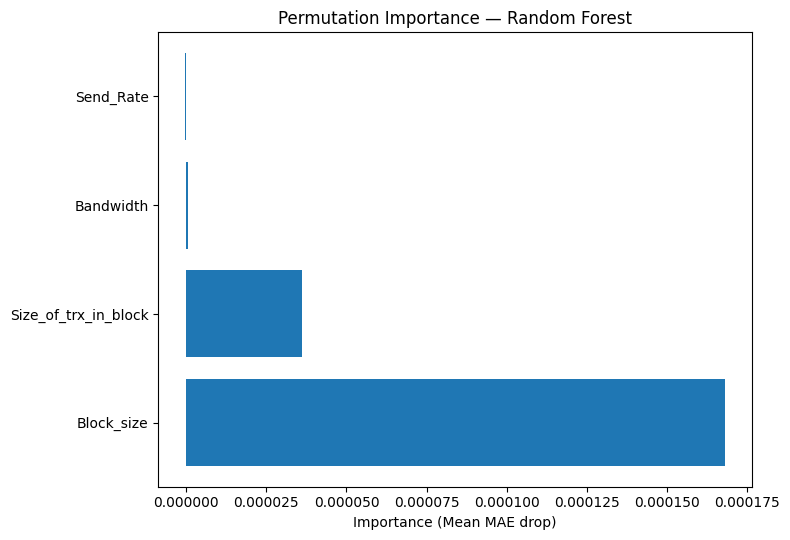

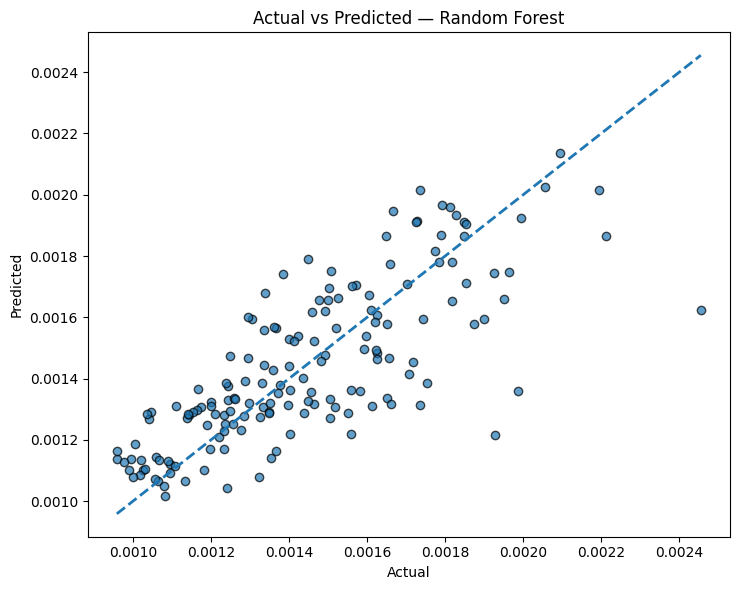

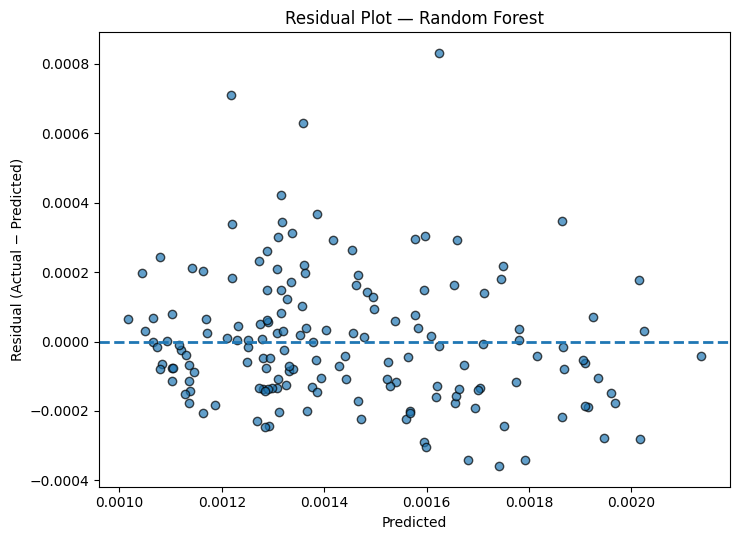

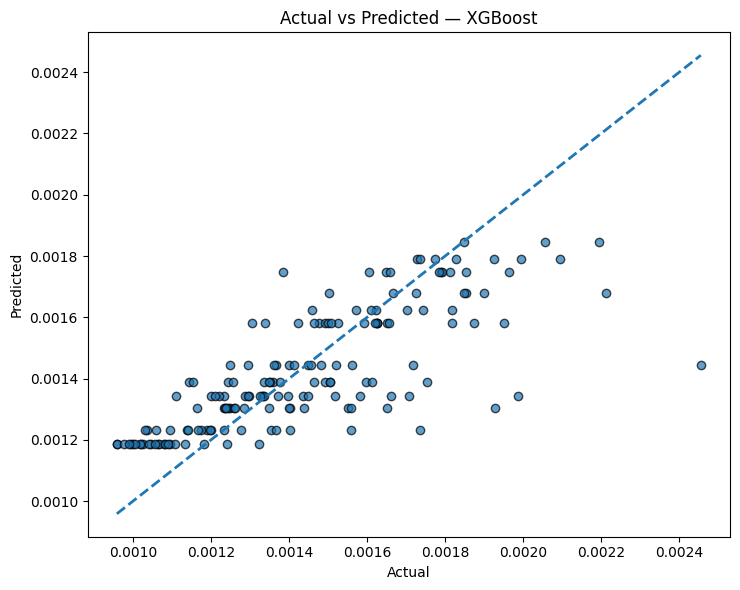

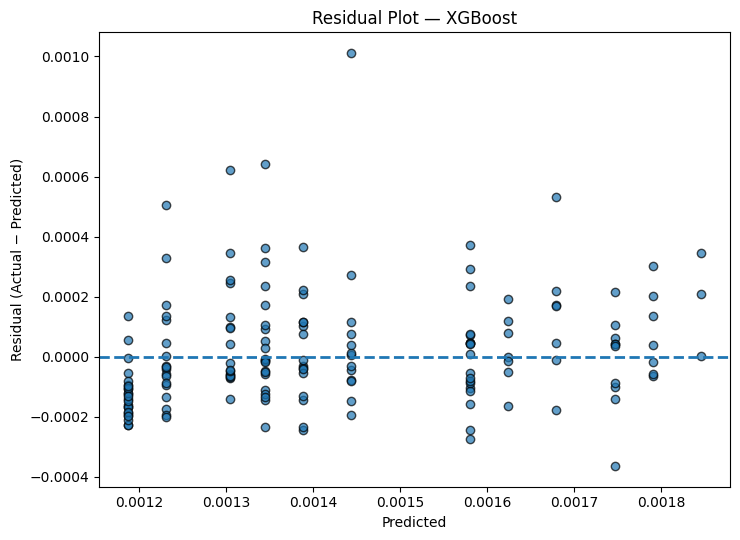

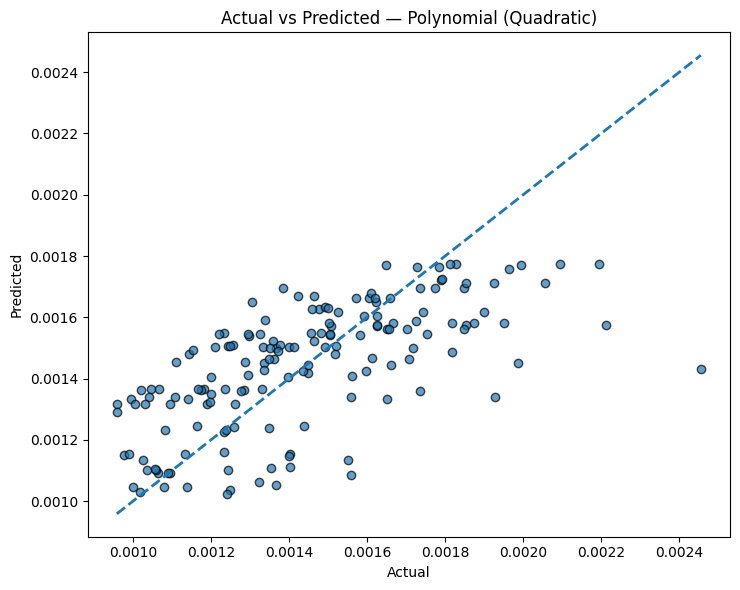

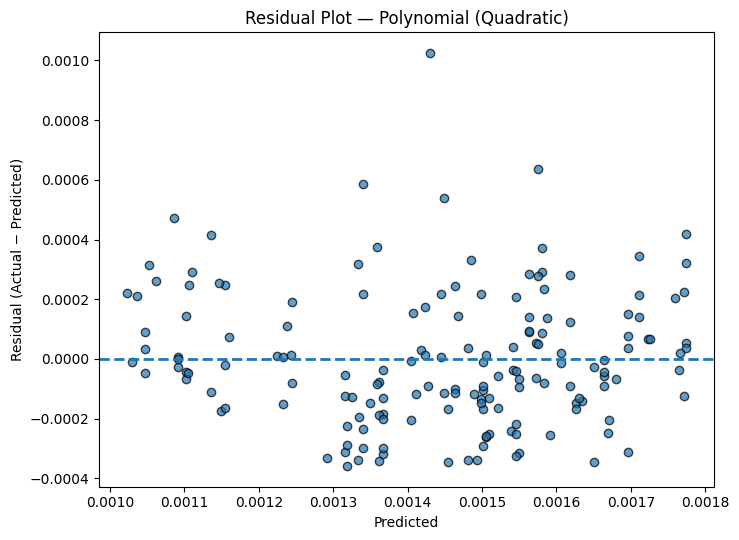

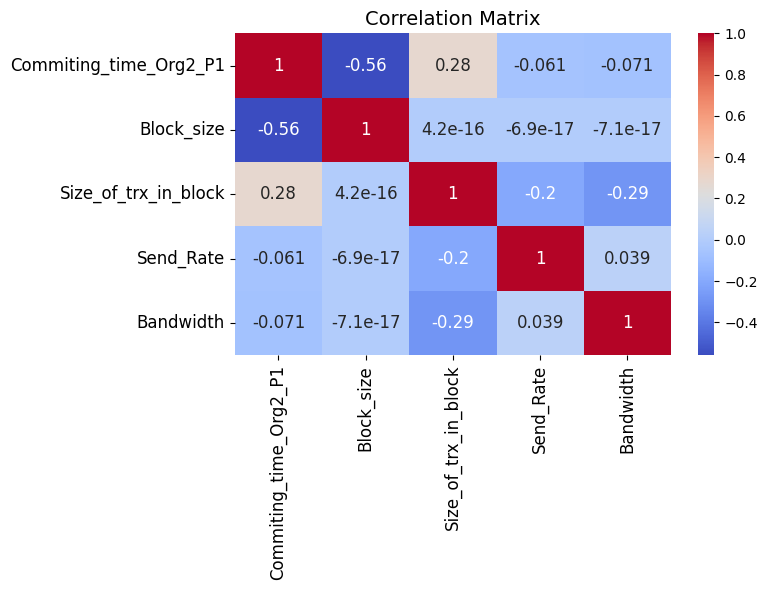

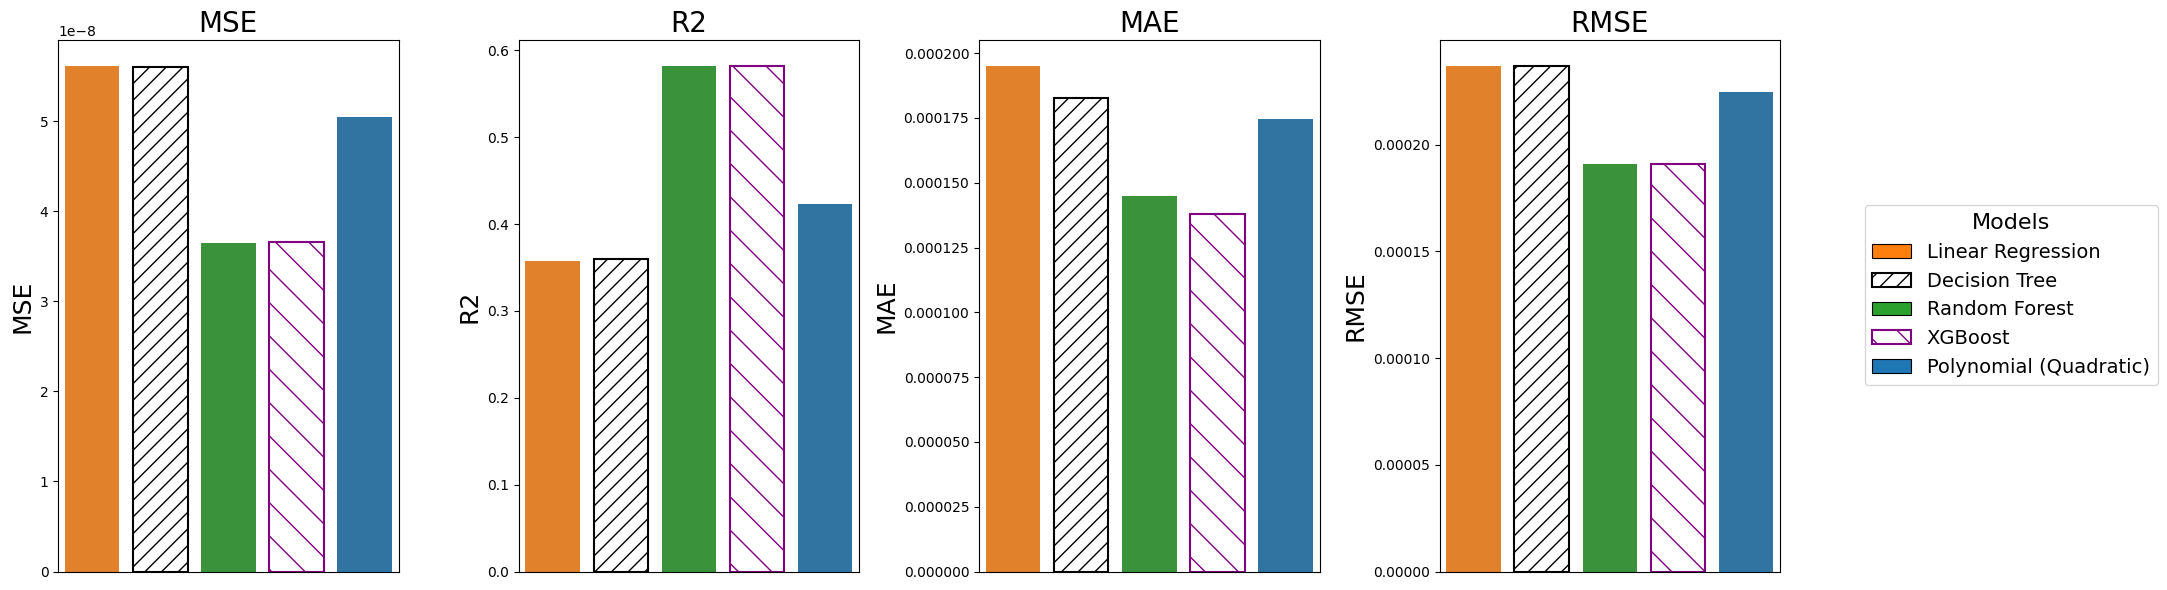

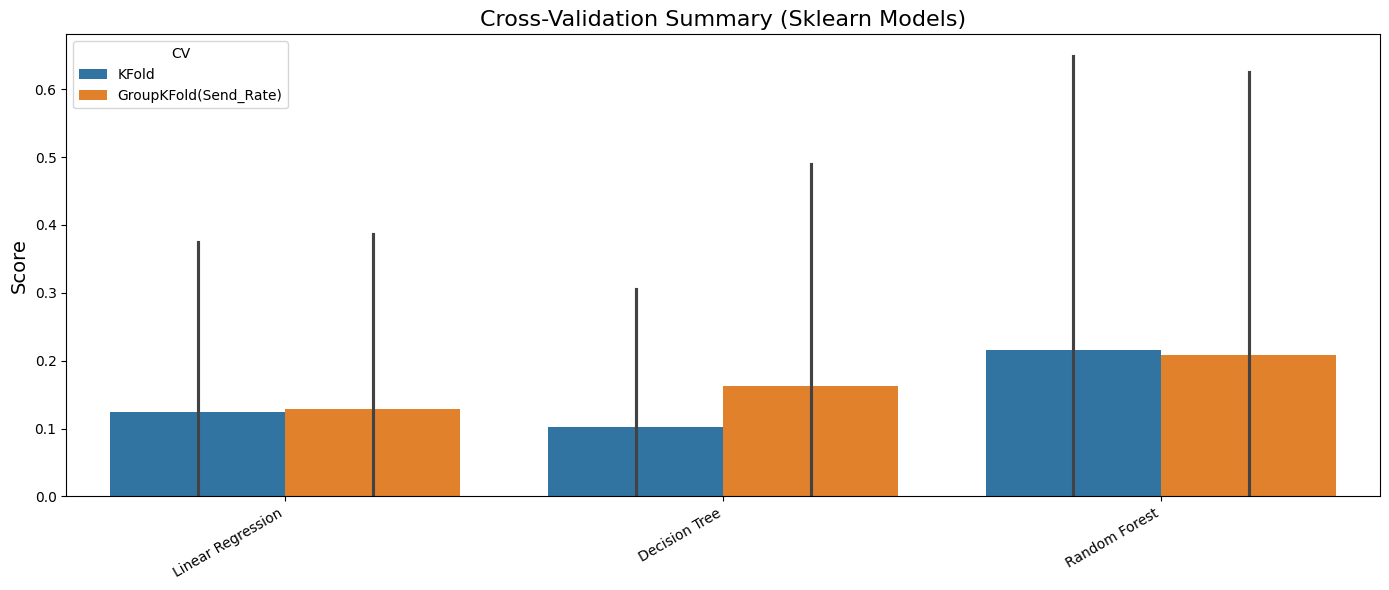


Saved models and quadratic artifacts successfully.


In [6]:
 #all model for peer0-Org1 validation time v2  


"""
Model comparison for Commiting_time_Org2_P1 (Org1 Peer0)

Goals (publication-friendly):
1) Train multiple regression models on the same feature set.
2) Report test-set metrics (MAE, RMSE, MSE, R2, MAPE) + simple baselines.
3) Run cross-validation:
   - KFold (random) for overall stability
   - GroupKFold (group by Send_Rate) to test generalization to unseen workload rates
4) Provide clean, consistent, high-quality plots:
   - Actual vs Predicted
   - Residual plots (diagnostic)
   - Metric comparison bars (MSE/R2/MAPE and MAE/RMSE/R2)
   - CV summary plot (MAE/RMSE/R2 from KFold and GroupKFold)

Notes on scaling:
- Tree-based models (DecisionTree/RandomForest/XGBoost) do NOT require feature scaling.
- Linear regression benefits from scaling only when regularization is used; plain LinearRegression is fine.
- Quadratic curve_fit DOES benefit from scaling (we scale only inside that block, without leakage).

Assumptions:
- df is already loaded and contains:
  Block_size, Size_of_trx_in_block, Send_Rate, Bandwidth, Commiting_time_Org2_P1
"""

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'pdf.fonttype': 42})

from sklearn.model_selection import train_test_split, KFold, GroupKFold, cross_validate
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.dummy import DummyRegressor

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

from sklearn.preprocessing import StandardScaler

from scipy.optimize import curve_fit
import xgboost as xgb

import matplotlib.patches as mpatches


# -----------------------------
# Helper metrics + plotting
# -----------------------------
def mean_absolute_percentage_error_safe(y_true, y_pred):
    """MAPE (%) ignoring zero targets to avoid division by zero."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)

def metrics_dict(y_true, y_pred):
    """Return standard regression metrics in a consistent dict."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error_safe(y_true, y_pred)
    return {"MAE": float(mae), "RMSE": rmse, "MSE": float(mse), "R2": float(r2), "MAPE(%)": float(mape)}

def plot_actual_vs_predicted(y_true, y_pred, model_name, save_pdf=False):
    plt.figure(figsize=(7.5, 6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolors='k')
    mn = min(np.min(y_true), np.min(y_pred))
    mx = max(np.max(y_true), np.max(y_pred))
    plt.plot([mn, mx], [mn, mx], '--', linewidth=2)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'Actual vs Predicted — {model_name}')
    plt.tight_layout()
    if save_pdf:
        plt.savefig(f'actual_vs_pred_{model_name.replace(" ", "_")}.pdf', dpi=600)
    plt.show()

def plot_residuals(y_true, y_pred, model_name, save_pdf=False):
    residuals = np.asarray(y_true) - np.asarray(y_pred)
    plt.figure(figsize=(7.5, 5.5))
    plt.scatter(y_pred, residuals, alpha=0.7, edgecolors='k')
    plt.axhline(0, linestyle='--', linewidth=2)
    plt.xlabel('Predicted')
    plt.ylabel('Residual (Actual − Predicted)')
    plt.title(f'Residual Plot — {model_name}')
    plt.tight_layout()
    if save_pdf:
        plt.savefig(f'residuals_{model_name.replace(" ", "_")}.pdf', dpi=600)
    plt.show()

def styled_metric_bars(plot_df, metric_names, title, filename_pdf, model_colors, hatch_rules):
    """
    Publication-friendly bar chart (one row per model, one panel per metric).
    Uses consistent colors and hatches for selected models.
    """
    melted = plot_df.melt(id_vars='Models', value_vars=metric_names, var_name='Metric', value_name='Score')

    plt.figure(figsize=(18, 6))
    for i, metric in enumerate(metric_names, 1):
        plt.subplot(1, len(metric_names), i)
        ax = sns.barplot(
            x='Models', y='Score',
            data=melted.query("Metric == @metric"),
            palette=[model_colors.get(m, '#FFFFFF') for m in plot_df['Models'].tolist()],
            hue='Models', dodge=False, legend=False
        )

        # Apply hatches/edges
        for bar, model in zip(ax.patches, plot_df['Models'].tolist()):
            hatch, face_none, edge_color, lw = hatch_rules.get(model, ("", False, None, 0.8))
            bar.set_hatch(hatch)

            if face_none:
                bar.set_facecolor('none')
            if edge_color is not None:
                bar.set_edgecolor(edge_color)
            bar.set_linewidth(lw)

        plt.title(metric, fontsize=20)
        plt.ylabel(metric, fontsize=18)
        plt.xlabel('')
        plt.xticks([], [])  # clean style like your old plot

    # Legend (custom, consistent with styles)
    legend_handles = []
    for m in plot_df['Models'].tolist():
        hatch, face_none, edge_color, lw = hatch_rules.get(m, ("", False, "black", 0.8))
        fc = 'none' if face_none else model_colors.get(m, '#FFFFFF')
        ec = edge_color if edge_color is not None else 'black'
        legend_handles.append(mpatches.Patch(facecolor=fc, edgecolor=ec, linewidth=lw, hatch=hatch, label=m))

    plt.gcf().legend(
        handles=legend_handles,
        loc='center',
        bbox_to_anchor=(1.12, 0.5),
        fontsize=14,
        title='Models',
        title_fontsize=16
    )

    plt.tight_layout()
    plt.savefig(filename_pdf, format='pdf', dpi=600, bbox_inches='tight')
    plt.show()


# -----------------------------
# 0) Data / Features
# -----------------------------
# df must exist already
# df.head()

feature_cols = ['Block_size', 'Size_of_trx_in_block', 'Send_Rate', 'Bandwidth']
target_col = 'Commiting_time_Org2_P1'

X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# 1) Baselines (sanity checks)
# -----------------------------
baseline_mean = DummyRegressor(strategy="mean")
baseline_mean.fit(X_train, y_train)
pred_mean = baseline_mean.predict(X_test)
print("Baseline (mean):", metrics_dict(y_test, pred_mean))

baseline_block_only = LinearRegression()
baseline_block_only.fit(X_train[['Block_size']], y_train)
pred_block_only = baseline_block_only.predict(X_test[['Block_size']])
print("Baseline (Block_size only):", metrics_dict(y_test, pred_block_only))


# -----------------------------
# 2) Train models (same split)
# -----------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    # XGBoost: keep sklearn wrapper for train/test evaluation
    "XGBoost": xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9
    ),
}

test_results = {}
y_preds = {}

for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    pred = mdl.predict(X_test)
    y_preds[name] = pred
    test_results[name] = metrics_dict(y_test, pred)

print("\n=== Test-set results (single split) ===")
for name in models.keys():
    r = test_results[name]
    print(f"\n{name}:")
    print(f"  MAE:     {r['MAE']:.10f}")
    print(f"  RMSE:    {r['RMSE']:.10f}")
    print(f"  MSE:     {r['MSE']:.10e}")
    print(f"  R2:      {r['R2']:.6f}")
    print(f"  MAPE(%): {r['MAPE(%)']:.4f}")


# -----------------------------
# 3) Quadratic regression (2 features) without leakage (curve_fit)
# -----------------------------
# This is a parametric baseline you can interpret and print as an equation.
quad_features = ['Block_size', 'Send_Rate']

def quadratic_model(X_arr, a, b, c, d, e, f):
    x1, x2 = X_arr
    return a * x1**2 + b * x1 * x2 + c * x2**2 + d * x1 + e * x2 + f

scaler_quad = StandardScaler()
X_train_q = scaler_quad.fit_transform(X_train[quad_features])
X_test_q = scaler_quad.transform(X_test[quad_features])

params, covariance = curve_fit(quadratic_model, X_train_q.T, y_train.values)
a, b, c, d, e, f = params

pred_quad = quadratic_model(X_test_q.T, *params)
test_results["Polynomial (Quadratic)"] = metrics_dict(y_test, pred_quad)
y_preds["Polynomial (Quadratic)"] = pred_quad

equation_scaled = (
    f"Validation_time = ({a:.6g} * x1^2) + ({b:.6g} * x1*x2) + ({c:.6g} * x2^2) "
    f"+ ({d:.6g} * x1) + ({e:.6g} * x2) + ({f:.6g}), "
    f"where x1,x2 are StandardScaler-transformed Block_size, Send_Rate."
)

print("\nPolynomial (Quadratic) equation (on standardized features):")
print(equation_scaled)


# -----------------------------
# 4) Cross-validation (publishable stability)
# -----------------------------
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

cv_kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# GroupKFold: generalize to unseen Send_Rate conditions
groups = df["Send_Rate"].astype(str)
cv_group = GroupKFold(n_splits=min(3, df["Send_Rate"].nunique()))

cv_summary = []

# IMPORTANT: sklearn cross_validate may fail with XGBoost+new sklearn in some environments.
# To keep this script robust + publishable: we do sklearn CV for sklearn models,
# and XGBoost CV using xgb.cv (official).
for name, mdl in models.items():
    if name == "XGBoost":
        continue

    out_k = cross_validate(mdl, X, y, cv=cv_kfold, scoring=scoring, return_train_score=False)
    out_g = cross_validate(mdl, X, y, cv=cv_group, groups=groups, scoring=scoring, return_train_score=False)

    cv_summary.append({
        "Models": name,
        "CV": "KFold",
        "MAE": float(-out_k["test_MAE"].mean()),
        "RMSE": float(-out_k["test_RMSE"].mean()),
        "R2": float(out_k["test_R2"].mean()),
    })
    cv_summary.append({
        "Models": name,
        "CV": "GroupKFold(Send_Rate)",
        "MAE": float(-out_g["test_MAE"].mean()),
        "RMSE": float(-out_g["test_RMSE"].mean()),
        "R2": float(out_g["test_R2"].mean()),
    })

# XGBoost CV (robust, official)
dtrain = xgb.DMatrix(X.values, label=y.values)
params_xgb = {
    "objective": "reg:squarederror",
    "seed": 42,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
}
cv_xgb = xgb.cv(
    params=params_xgb,
    dtrain=dtrain,
    num_boost_round=800,
    nfold=5,
    metrics=("rmse",),
    early_stopping_rounds=30,
    seed=42,
    verbose_eval=False
)
xgb_rmse = float(cv_xgb["test-rmse-mean"].iloc[-1])

print("\nXGBoost 5-fold CV (xgb.cv):")
print("  RMSE mean (last):", xgb_rmse)
print("  RMSE std  (last):", float(cv_xgb["test-rmse-std"].iloc[-1]))


cv_df = pd.DataFrame(cv_summary)
print("\n=== CV summary (sklearn models) ===")
print(cv_df)


# -----------------------------
# 5) Permutation importance (more reliable than tree impurity importance)
# -----------------------------
# Choose a best model for importance 
# Pick best model by lowest RMSE on the test set
best_model_name = min(test_results.keys(), key=lambda m: test_results[m]["RMSE"])

# Only sklearn models are in `models` (Quadratic isn't), so handle that case
if best_model_name in models:
    best_model = models[best_model_name]
else:
    best_model = None  # Quadratic

print("\nBest model (by Test RMSE):", best_model_name, test_results[best_model_name])

perm = permutation_importance(
    best_model,
    X_test, y_test,
    n_repeats=25,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

perm_imp = pd.DataFrame({
    "Feature": X_test.columns,
    "ImportanceMean(MAE drop)": perm.importances_mean,
    "ImportanceStd": perm.importances_std
}).sort_values("ImportanceMean(MAE drop)", ascending=False)

print("\nPermutation importance (MAE drop):")
print(perm_imp)

# Plot permutation importances
plt.figure(figsize=(8, 5.5))
plt.barh(perm_imp["Feature"], perm_imp["ImportanceMean(MAE drop)"])
plt.xlabel("Importance (Mean MAE drop)")
plt.title(f"Permutation Importance — {best_model_name}")
plt.tight_layout()
plt.savefig("permutation_importance.pdf", dpi=600)
plt.show()


# -----------------------------
# 6) Publication plots
# -----------------------------
# 6.1 Actual vs predicted + residuals (pick top models)
for nm in ["Random Forest", "XGBoost", "Polynomial (Quadratic)"]:
    plot_actual_vs_predicted(y_test, y_preds[nm], nm, save_pdf=True)
    plot_residuals(y_test, y_preds[nm], nm, save_pdf=True)

# 6.2 Keep your correlation plot (optional)
corr_cols = [target_col] + feature_cols
correlation_matrix = df[corr_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 12})
plt.title("Correlation Matrix", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('validation_correlation_matrix.pdf', format='pdf', dpi=600)
plt.show()

# 6.3 Metric comparison plots (bars) in your style (colors + hatches)
# Build a single test-results table for plotting
plot_models_order = [
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost",
    "Polynomial (Quadratic)"
]
plot_table = pd.DataFrame([
    {"Models": m,
     "MSE": test_results[m]["MSE"],
     "R2": test_results[m]["R2"],
     "MAPE": test_results[m]["MAPE(%)"],
     "MAE": test_results[m]["MAE"],
     "RMSE": test_results[m]["RMSE"]}
    for m in plot_models_order
])

# Colors (keep your original palette idea )
model_colors = {
    "Linear Regression": "#ff7f0e",
    "Decision Tree": "none",
    "Random Forest": "#2ca02c",
    "XGBoost": "none",
    "Polynomial (Quadratic)": "#1f77b4",
}

# Hatch rules: (hatch, face_none, edge_color, linewidth)
hatch_rules = {
    "Decision Tree": ("//", True, "black", 1.5),
    "XGBoost": ("\\", True, "#800080", 1.5),
    # others default
}

# Plot A: your original trio (MSE, R2, MAPE)
styled_metric_bars(
    plot_df=plot_table[["Models", "MSE", "R2","MAE", "RMSE"]],
    metric_names=["MSE", "R2","MAE", "RMSE"],
    title="Model Comparison (Test Set)",
    filename_pdf="validation_models_mse_r2_mape.pdf",
    model_colors=model_colors,
    hatch_rules=hatch_rules
)



# 6.4 CV summary plot (KFold vs GroupKFold)
if not cv_df.empty:
    # Pivot into long format for plotting
    cv_plot = cv_df.melt(id_vars=["Models", "CV"], value_vars=["MAE", "RMSE", "R2"],
                         var_name="Metric", value_name="Score")

    plt.figure(figsize=(14, 6))
    ax = sns.barplot(data=cv_plot, x="Models", y="Score", hue="CV")
    plt.title("Cross-Validation Summary (Sklearn Models)", fontsize=16)
    plt.ylabel("Score", fontsize=14)
    plt.xlabel("")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig("cv_summary.pdf", dpi=600)
    plt.show()


# -----------------------------
# 7) Save fitted models/objects (for reuse)
# -----------------------------
import joblib

joblib.dump(models["Linear Regression"], "CP1Org2_linear_model.pkl")
joblib.dump(models["Decision Tree"], "CP1Org2_tree_model.pkl")
joblib.dump(models["Random Forest"], "CP1Org2_forest_model.pkl")
joblib.dump(models["XGBoost"], "CP1Org2_xgboost_model.pkl")

# Quadratic params + scaler for later prediction
joblib.dump(params, "CP1Org2_quadratic_params.pkl")
joblib.dump(scaler_quad, "CP1Org2_quadratic_scaler.pkl")

print("\nSaved models and quadratic artifacts successfully.")

